# Exploratory Data Analysis

This notebook is the comprehensive EDA reference. It uses the **eda_starter_template** module to load data, run analyses, and generate visualizations. All exploratory work and supporting results are included here; the executive summary lives in `EDA_Executive.ipynb`.

## Fear and Greed Index Exploration

The **Crypto Fear and Greed Index (FGI)**, developed by Alternative.me, is a composite sentiment metric that measures the prevailing psychological state of the market on a scale from 0 to 100. Rather than looking strictly at price, the index calculates a "magic number" by aggregating six distinct quantitative and qualitative indicators:
* **Volatility (25%):** Current price swings compared to 30- and 90-day averages.
* **Market Momentum & Volume (25%):** Current buying/selling volume against 30- and 90-day trends.
* **Social Media (15%):** Interaction rates, hashtags, and public interest on platforms like Twitter.
* **Surveys (15%):** Weekly polling of individual investor outlooks.
* **Bitcoin Dominance (10%):** BTC's market cap share relative to speculative altcoins.
* **Search Trends (10%):** Google search volumes for specific Bitcoin-related queries.

### Why is it relevant?
In a Bitcoin accumulation model, market psychology is just as critical as raw price action. By quantifying human emotion, the FGI acts as a powerful **contrarian indicator**:
* **Extreme Fear (0-24):** Indicates investors are overly bearish. This often correlates with market capitulation, potential undervaluation, and an optimal time to increase accumulation (buy the dip).
* **Extreme Greed (76-100):** Indicates investors are overly bullish. This signals market froth, overvaluation, and an optimal time to decrease accumulation or begin distribution (taking profits).

### What are we trying to do?
In this section, we will load the historical FGI dataset from our local `data/` folder, merge it with our Bitcoin price history, and rigorously backtest its relationship against future price momentum. Our goal is to determine if these sentiment extremes can serve as reliable algorithmic triggers to optimize when we buy and when we sell.

In [103]:
# Setup: use eda_starter_template from this repo
import sys
from pathlib import Path

# Dynamically resolve the current working directory
cwd = Path.cwd().parent

# If the notebook is running from the project root
if (cwd / "eda" / "eda_starter_template.py").exists():
    sys.path.insert(0, str(cwd))
    from eda.eda_starter_template import (
        load_bitcoin_data,
        load_polymarket_data,
        COINMETRICS_PATH,
        POLYMARKET_DIR,
        analyze_btc_metrics,
        analyze_polymarket_summary,
        plot_btc_price,
        plot_polymarket_volume,
        track_memory,
        get_memory_usage_mb,
        format_memory,
        PLOTS_DIR,
    )
# If the notebook is running from inside the 'eda' directory
elif (cwd / "eda_starter_template.py").exists():
    # Insert the parent directory into sys.path just in case other modules need it
    sys.path.insert(0, str(cwd.parent))
    from eda_starter_template import (
        load_bitcoin_data,
        load_polymarket_data,
        COINMETRICS_PATH,
        POLYMARKET_DIR,
        analyze_btc_metrics,
        analyze_polymarket_summary,
        plot_btc_price,
        plot_polymarket_volume,
        track_memory,
        get_memory_usage_mb,
        format_memory,
        PLOTS_DIR,
    )
else:
    raise ImportError(f"Could not find eda_starter_template.py from {cwd}. Run notebook from project root or eda/.")

print("Initial memory:", format_memory(get_memory_usage_mb()))

Initial memory: 311.18 MB


In [104]:
btc_df = load_bitcoin_data(COINMETRICS_PATH)
if btc_df is not None:
    display(btc_df.head())
    print("Shape:", btc_df.shape)

Loading Bitcoin data from C:\Users\eschi\Documents\CSE 7648\bitcoin-analytics-capstone-template-agopalkr\data\Coin Metrics\coinmetrics_btc.csv...
[Memory] Before loading Bitcoin data: 311.18 MB
[Memory] After loading Bitcoin data: 316.38 MB (Δ 5.20 MB)
Successfully loaded 6221 rows.


time,AdrActCnt,AdrBalCnt,AssetCompletionTime,AssetEODCompletionTime,BlkCnt,CapMVRVCur,CapMrktCurUSD,CapMrktEstUSD,FeeTotNtv,FlowInExNtv,FlowInExUSD,FlowOutExNtv,FlowOutExUSD,HashRate,IssTotNtv,IssTotUSD,PriceBTC,PriceUSD,ROI1yr,ROI30d,ReferenceRate,ReferenceRateETH,ReferenceRateEUR,ReferenceRateUSD,SplyCur,SplyExNtv,SplyExUSD,SplyExpFut10yr,TxCnt,TxTfrCnt,volume_reported_spot_usd_1d
datetime[μs],i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,i64,f64
2009-01-03 00:00:00,0,0,1614334883,1614334883,0,null,null,null,0.0,0.0,null,0.0,null,null,null,null,1,null,null,null,null,null,null,null,0.0,0.0,null,null,0,0,null
2009-01-04 00:00:00,0,0,1614334883,1614334883,0,null,null,null,0.0,0.0,null,0.0,null,null,null,null,1,null,null,null,null,null,null,null,0.0,0.0,null,null,0,0,null
2009-01-05 00:00:00,0,0,1614334883,1614334883,0,null,null,null,0.0,0.0,null,0.0,null,null,null,null,1,null,null,null,null,null,null,null,0.0,0.0,null,null,0,0,null
2009-01-06 00:00:00,0,0,1614334884,1614334884,0,null,null,null,0.0,0.0,null,0.0,null,null,null,null,1,null,null,null,null,null,null,null,0.0,0.0,null,null,0,0,null
2009-01-07 00:00:00,0,0,1614334885,1614334885,0,null,null,null,0.0,0.0,null,0.0,null,null,null,null,1,null,null,null,null,null,null,null,0.0,0.0,null,null,0,0,null


Shape: (6221, 32)


In [105]:
import pandas as pd
from pathlib import Path

# Dynamically route the path based on the notebook's current working directory
current_dir = Path.cwd()

# Check if 'data' is in the current directory (if notebook is in repo root)
# Or if it's one level up (if notebook is inside a 'notebooks' subfolder)
if (current_dir / "data").exists():
    data_dir = current_dir / "data"
else:
    data_dir = current_dir.parent / "data"

# Construct the OS-agnostic path to the CSV file
file_path = data_dir / "crypto_fear_and_greed_index_2019_2025.csv"

print(f"Attempting to load FGI data from: {file_path}")

if file_path.exists():
    # Load the CSV into a pandas DataFrame
    fgi_df = pd.read_csv(file_path)

    # Ensure the 'date' column is correctly parsed as a date object for merging later
    fgi_df['date'] = pd.to_datetime(fgi_df['date']).dt.date

    print(f" Successfully loaded {len(fgi_df)} records.")
    display(fgi_df.head())
else:
    print(f" File not found at: {file_path}")
    print("Please ensure the data file exists in the repository's 'data' folder.")

Attempting to load FGI data from: C:\Users\eschi\Documents\CSE 7648\bitcoin-analytics-capstone-template-agopalkr\data\crypto_fear_and_greed_index_2019_2025.csv
 Successfully loaded 2557 records.


,date,value,value_classification
0,2019-01-01,24,Extreme Fear
1,2019-01-02,30,Fear
2,2019-01-03,33,Fear
3,2019-01-04,48,Neutral
4,2019-01-05,36,Fear


In [106]:
# import pandas as pd
# import polars as pl

# # Convert Polars -> Pandas first so we can use pd.merge
# btc_df_pd = btc_df.to_pandas()

# # Convert 'time' column in btc_df_pd to date objects to match fgi_df['date']
# btc_df_pd['time'] = pd.to_datetime(btc_df_pd['time']).dt.date

# # fgi_df['date'] is already converted to date objects in the previous cell (cc147ad4-071a-42be-bd24-f97d0618a44b).
# # No need to convert fgi_df['date'] again here.

# # Merge the two DataFrames on their respective date columns
# # Left merge keeps all Bitcoin price data and adds FGI where available
# merged_fgi_btc_pd = pd.merge(
#     btc_df_pd, fgi_df,
#     left_on='time', right_on='date',
#     how='left'
# )

# # Drop the redundant 'date' column from fgi_df, keeping 'time' as the primary date column
# merged_fgi_btc_pd = merged_fgi_btc_pd.drop(columns=['date'])

# # Convert back to Polars for subsequent usage
# # The primary date column is now 'time'
# merged_fgi_btc = pl.from_pandas(merged_fgi_btc_pd)

# print("Merged Polars DataFrame 'merged_fgi_btc' created successfully.")
# print("Columns:", merged_fgi_btc.columns)
# display(merged_fgi_btc.head())
# print("Shape:", merged_fgi_btc.shape)

In [107]:
import pandas as pd
import polars as pl

# Ensure 'Date' column in btc_df is in datetime format
# Convert Polars -> Pandas first so we can use pd.merge
btc_df_pd = btc_df.to_pandas()
btc_df_pd = btc_df_pd.rename(columns={"time": "Date"})
btc_df_pd['Date'] = pd.to_datetime(btc_df_pd['Date']).dt.date

# Convert 'date' column in fgi_df to datetime
#fgi_df['date'] = pd.to_datetime(fgi_df['date'])

# Merge the two DataFrames on their respective date columns
# Left merge keeps all Bitcoin price data and adds FGI where available
merged_fgi_btc_pd = pd.merge(
    btc_df_pd, fgi_df,
    left_on='Date', right_on='date',
    how='inner'
)

# Drop the redundant 'date' column from fgi_df
merged_fgi_btc_pd = merged_fgi_btc_pd.drop(columns=['date'])

# Rename 'Date' to 'date' for consistency
merged_fgi_btc_pd = merged_fgi_btc_pd.rename(columns={'Date': 'date'})

# Convert back to Polars for subsequent usage
merged_fgi_btc = pl.from_pandas(merged_fgi_btc_pd)

print("Merged Polars DataFrame 'merged_fgi_btc' created successfully.")
print("Columns:", merged_fgi_btc.columns)
display(merged_fgi_btc.head())
print("Shape:", merged_fgi_btc.shape)

Merged Polars DataFrame 'merged_fgi_btc' created successfully.
Columns: ['date', 'AdrActCnt', 'AdrBalCnt', 'AssetCompletionTime', 'AssetEODCompletionTime', 'BlkCnt', 'CapMVRVCur', 'CapMrktCurUSD', 'CapMrktEstUSD', 'FeeTotNtv', 'FlowInExNtv', 'FlowInExUSD', 'FlowOutExNtv', 'FlowOutExUSD', 'HashRate', 'IssTotNtv', 'IssTotUSD', 'PriceBTC', 'PriceUSD', 'ROI1yr', 'ROI30d', 'ReferenceRate', 'ReferenceRateETH', 'ReferenceRateEUR', 'ReferenceRateUSD', 'SplyCur', 'SplyExNtv', 'SplyExUSD', 'SplyExpFut10yr', 'TxCnt', 'TxTfrCnt', 'volume_reported_spot_usd_1d', 'value', 'value_classification']


date,AdrActCnt,AdrBalCnt,AssetCompletionTime,AssetEODCompletionTime,BlkCnt,CapMVRVCur,CapMrktCurUSD,CapMrktEstUSD,FeeTotNtv,FlowInExNtv,FlowInExUSD,FlowOutExNtv,FlowOutExUSD,HashRate,IssTotNtv,IssTotUSD,PriceBTC,PriceUSD,ROI1yr,ROI30d,ReferenceRate,ReferenceRateETH,ReferenceRateEUR,ReferenceRateUSD,SplyCur,SplyExNtv,SplyExUSD,SplyExpFut10yr,TxCnt,TxTfrCnt,volume_reported_spot_usd_1d,value,value_classification
date,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,str
2019-01-01,433715.0,2.2399091e7,1.6143e9,1.6143e9,149.0,0.8391035,6.6480e10,null,11.263483,12398.804912,4.7216e7,14216.390018,5.4138e7,4.1616e7,1862.5,7.0926e6,1.0,3808.117832,-71.71767,-7.090678,null,null,null,null,1.7457e7,1.5331e6,5.8381e9,2.0394e7,235813.0,448759.0,6.6514e8,24,"""Extreme Fear"""
2019-01-02,578607.0,2.2376168e7,1.6143e9,1.6143e9,151.0,0.859073,6.8060e10,null,18.195239,25609.499964,9.9831e7,29015.52783,1.1311e8,4.2175e7,1887.5,7.3578e6,1.0,3898.197488,-73.579285,1.41054,null,null,null,null,1.7459e7,1.5297e6,5.9629e9,2.0394e7,271103.0,545632.0,9.0733e8,30,"""Fear"""
2019-01-03,598436.0,2.2383153e7,1.6143e9,1.6143e9,155.0,0.834871,6.6080e10,null,19.07118,26211.564461,9.9195e7,33576.697372,1.2707e8,4.3292e7,1937.5,7.3323e6,1.0,3784.388635,-74.788031,-2.788707,null,null,null,null,1.7461e7,1.5223e6,5.7610e9,2.0395e7,287081.0,599287.0,7.4191e8,33,"""Fear"""
2019-01-04,580495.0,2.2398175e7,1.6143e9,1.6143e9,149.0,0.8447265,6.6841e10,null,19.3568,26932.229289,1.0308e8,29477.335063,1.1283e8,4.1616e7,1862.5,7.1288e6,1.0,3827.524594,-74.602202,3.181105,null,null,null,null,1.7463e7,1.5198e6,5.8169e9,2.0395e7,283490.0,581832.0,9.2437e8,48,"""Neutral"""
2019-01-05,519070.0,2.2413983e7,1.6143e9,1.6143e9,163.0,0.838567,6.6344e10,null,12.551464,21120.885749,8.0230e7,15219.257152,5.7812e7,4.5526e7,2037.5,7.7397e6,1.0,3798.613955,-77.651567,8.161945,null,null,null,null,1.7465e7,1.5257e6,5.7954e9,2.0395e7,269637.0,533367.0,8.2544e8,36,"""Fear"""


Shape: (2557, 34)


In [108]:
merged_fgi_btc

date,AdrActCnt,AdrBalCnt,AssetCompletionTime,AssetEODCompletionTime,BlkCnt,CapMVRVCur,CapMrktCurUSD,CapMrktEstUSD,FeeTotNtv,FlowInExNtv,FlowInExUSD,FlowOutExNtv,FlowOutExUSD,HashRate,IssTotNtv,IssTotUSD,PriceBTC,PriceUSD,ROI1yr,ROI30d,ReferenceRate,ReferenceRateETH,ReferenceRateEUR,ReferenceRateUSD,SplyCur,SplyExNtv,SplyExUSD,SplyExpFut10yr,TxCnt,TxTfrCnt,volume_reported_spot_usd_1d,value,value_classification
date,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,str
2019-01-01,433715.0,2.2399091e7,1.6143e9,1.6143e9,149.0,0.8391035,6.6480e10,null,11.263483,12398.804912,4.7216e7,14216.390018,5.4138e7,4.1616e7,1862.5,7.0926e6,1.0,3808.117832,-71.71767,-7.090678,null,null,null,null,1.7457e7,1.5331e6,5.8381e9,2.0394e7,235813.0,448759.0,6.6514e8,24,"""Extreme Fear"""
2019-01-02,578607.0,2.2376168e7,1.6143e9,1.6143e9,151.0,0.859073,6.8060e10,null,18.195239,25609.499964,9.9831e7,29015.52783,1.1311e8,4.2175e7,1887.5,7.3578e6,1.0,3898.197488,-73.579285,1.41054,null,null,null,null,1.7459e7,1.5297e6,5.9629e9,2.0394e7,271103.0,545632.0,9.0733e8,30,"""Fear"""
2019-01-03,598436.0,2.2383153e7,1.6143e9,1.6143e9,155.0,0.834871,6.6080e10,null,19.07118,26211.564461,9.9195e7,33576.697372,1.2707e8,4.3292e7,1937.5,7.3323e6,1.0,3784.388635,-74.788031,-2.788707,null,null,null,null,1.7461e7,1.5223e6,5.7610e9,2.0395e7,287081.0,599287.0,7.4191e8,33,"""Fear"""
2019-01-04,580495.0,2.2398175e7,1.6143e9,1.6143e9,149.0,0.8447265,6.6841e10,null,19.3568,26932.229289,1.0308e8,29477.335063,1.1283e8,4.1616e7,1862.5,7.1288e6,1.0,3827.524594,-74.602202,3.181105,null,null,null,null,1.7463e7,1.5198e6,5.8169e9,2.0395e7,283490.0,581832.0,9.2437e8,48,"""Neutral"""
2019-01-05,519070.0,2.2413983e7,1.6143e9,1.6143e9,163.0,0.838567,6.6344e10,null,12.551464,21120.885749,8.0230e7,15219.257152,5.7812e7,4.5526e7,2037.5,7.7397e6,1.0,3798.613955,-77.651567,8.161945,null,null,null,null,1.7465e7,1.5257e6,5.7954e9,2.0395e7,269637.0,533367.0,8.2544e8,36,"""Fear"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2025-12-27,569638.0,5.572814e7,1.7669e9,1.7669e9,136.0,1.56113,1.7511e12,1.7511e12,2.079782,9435.308947,8.2743e8,11654.1703,1.0220e9,1.0023e9,425.0,3.7271e7,1.0,87695.415908,-6.924822,-3.986135,null,null,null,null,1.9968e7,2.5040e6,2.1959e11,2.0825e7,475008.0,1.027864e6,3.2606e9,23,"""Extreme Fear"""
2025-12-28,572908.0,5.5752466e7,1.7670e9,1.7670e9,155.0,1.562371,1.7522e12,1.7521e12,2.155405,9847.439706,8.6409e8,8435.604083,7.4020e8,1.1423e9,484.375,4.2503e7,1.0,87747.649155,-7.754052,-3.563549,null,null,null,null,1.9968e7,2.5060e6,2.1990e11,2.0825e7,540696.0,1.15537e6,4.0297e9,24,"""Extreme Fear"""
2025-12-29,693511.0,5.5767043e7,1.7671e9,1.7671e9,154.0,1.551844,1.7400e12,1.7399e12,2.806141,32455.348312,2.8279e9,34643.596758,3.0186e9,1.1350e9,481.25,4.1933e7,1.0,87133.510399,-6.766779,-4.082429,null,null,null,null,1.9969e7,2.5044e6,2.1822e11,2.0825e7,548253.0,1.175491e6,1.5863e10,24,"""Extreme Fear"""


In [109]:
# Option 1: Using .shape
print("Row count:", merged_fgi_btc.shape[0])

# Option 2: Using .height (Polars shortcut)
print("Row count:", merged_fgi_btc.height)

Row count: 2557
Row count: 2557


In [118]:
import polars as pl
import datetime as dt

# 1. Prepare Data
merged_fgi_btc = merged_fgi_btc.with_columns(
    pl.col("date").cast(pl.Datetime)
)

start_date = dt.datetime(2019, 1, 1)
end_date   = dt.datetime(2025, 12, 31)

dca_df = merged_fgi_btc.filter(
    (pl.col("date") >= start_date) & (pl.col("date") <= end_date)
).sort("date")

# 2. Daily Base Metrics
# Calculate raw Sats per Dollar for every day
dca_df = dca_df.with_columns([
    (100_000_000 / pl.col("PriceUSD")).alias("inv_price")
])

# Generate the raw FGI multipliers
dca_df = dca_df.with_columns(
    pl.when(pl.col("value").is_null()).then(1.0)
    .when(pl.col("value") <= 24).then(1.5)   # Extreme Fear
    .when(pl.col("value") <= 44).then(1.2)   # Fear
    .when(pl.col("value") <= 55).then(1.0)   # Neutral
    .when(pl.col("value") <= 75).then(0.8)   # Greed
    .otherwise(0.5)                          # Extreme Greed
    .alias("fgi_multiplier")
)

# Calculate the weighted daily investment
dca_df = dca_df.with_columns([
    (pl.col("inv_price") * pl.col("fgi_multiplier")).alias("weighted_inv_price")
])

# 3. Rolling 1-Year Window Backtest (365 days)
window_size = 365

# Calculate rolling aggregates for the window
dca_df = dca_df.with_columns([
    # Uniform DCA SPD is just the mean of daily sats-per-dollar
    pl.col("inv_price").rolling_mean(window_size).alias("uniform_spd"),

    # Dynamic DCA SPD is the sum of weighted prices divided by the sum of the weights
    (pl.col("weighted_inv_price").rolling_sum(window_size) / pl.col("fgi_multiplier").rolling_sum(window_size)).alias("dynamic_spd"),

    # Min/Max possible SPD in the window (for percentile normalization)
    pl.col("inv_price").rolling_min(window_size).alias("min_spd"),
    pl.col("inv_price").rolling_max(window_size).alias("max_spd")
])

# 4. Calculate Percentiles
dca_df = dca_df.with_columns([
    ((pl.col("uniform_spd") - pl.col("min_spd")) / (pl.col("max_spd") - pl.col("min_spd")) * 100).alias("uniform_percentile"),
    ((pl.col("dynamic_spd") - pl.col("min_spd")) / (pl.col("max_spd") - pl.col("min_spd")) * 100).alias("dynamic_percentile")
])

# 5. Evaluation and Output Metrics
# Drop the first 364 days which do not form a complete 1-year window
valid_windows = dca_df.drop_nulls(subset=["uniform_percentile", "dynamic_percentile"])

total_windows = valid_windows.height
wins = valid_windows.filter(pl.col("dynamic_percentile") > pl.col("uniform_percentile")).height
win_rate = (wins / total_windows) * 100

# Aggregate metrics matching the template output format
dyn_spd_mean = valid_windows["dynamic_spd"].mean()
dyn_spd_median = valid_windows["dynamic_spd"].median()
dyn_pct_mean = valid_windows["dynamic_percentile"].mean()
dyn_pct_median = valid_windows["dynamic_percentile"].median()

excess_percentile = valid_windows["dynamic_percentile"] - valid_windows["uniform_percentile"]
mean_excess = excess_percentile.mean()

print(f"Backtesting date range: {start_date.date()} to {end_date.date()} ({total_windows} total windows)")
print("\nAggregated Metrics for Dynamic DCA:")
print(f"  SPD: mean={dyn_spd_mean:.2f}, median={dyn_spd_median:.2f}")
print(f"  Percentile: mean={dyn_pct_mean:.2f}%, median={dyn_pct_median:.2f}%")
print(f"\nSummary: {total_windows - wins}/{total_windows} underperformed ({win_rate:.2f}% win rate)")

if win_rate >= 50.0:
    print("✅ Strategy meets performance requirement (≥ 50% win rate vs. uniform DCA).")
else:
    print("❌ Strategy failed performance requirement (< 50% win rate).")

print(f"\nFinal Metrics Preview:")
print(f"  Mean Excess: {mean_excess:+.2f}%")

Backtesting date range: 2019-01-01 to 2025-12-31 (2193 total windows)

Aggregated Metrics for Dynamic DCA:
  SPD: mean=4902.95, median=3417.74
  Percentile: mean=41.11%, median=41.74%

Summary: 163/2193 underperformed (92.57% win rate)
✅ Strategy meets performance requirement (≥ 50% win rate vs. uniform DCA).

Final Metrics Preview:
  Mean Excess: +2.83%


In [139]:
print(dca_df['inv_price'].sum())
print(dca_df['weighted_inv_price'].sum())

14017758.900938243
15207099.435636852


In [115]:
dca_df['fgi_multiplier'].mean()

1.0235041063746575

In [134]:
# 1. Isolate a single 365-day window (e.g., the very last year of the backtest)
sample_window = dca_df.tail(365)

# 2. Find the total sum of the raw multipliers for THESE specific 365 days
sum_of_weights = sample_window["fgi_multiplier"].sum()

# 3. Calculate what fraction of the window's total budget was spent on each day
sample_window = sample_window.with_columns([
    (pl.col("fgi_multiplier") / sum_of_weights).alias("daily_fraction")
])

# 4. Prove that it adds up to exactly 1.0 (100% of the budget)
total_fraction = sample_window["daily_fraction"].sum()

# If our budget is $365 for the year ($1 per day standard DCA), how much did we spend?
total_budget_spent = total_fraction * 365

print(f"Sum of raw multipliers in this window: {sum_of_weights:.2f}")
print(f"Sum of daily fractions: {total_fraction:.5f} (100%)")
print(f"Total fiat spent in this window: ${total_budget_spent:.2f}")

Sum of raw multipliers in this window: 378.50
Sum of daily fractions: 1.00000 (100%)
Total fiat spent in this window: $365.00


In [140]:
sample_window['fgi_multiplier'].mean()

1.0369863013698633

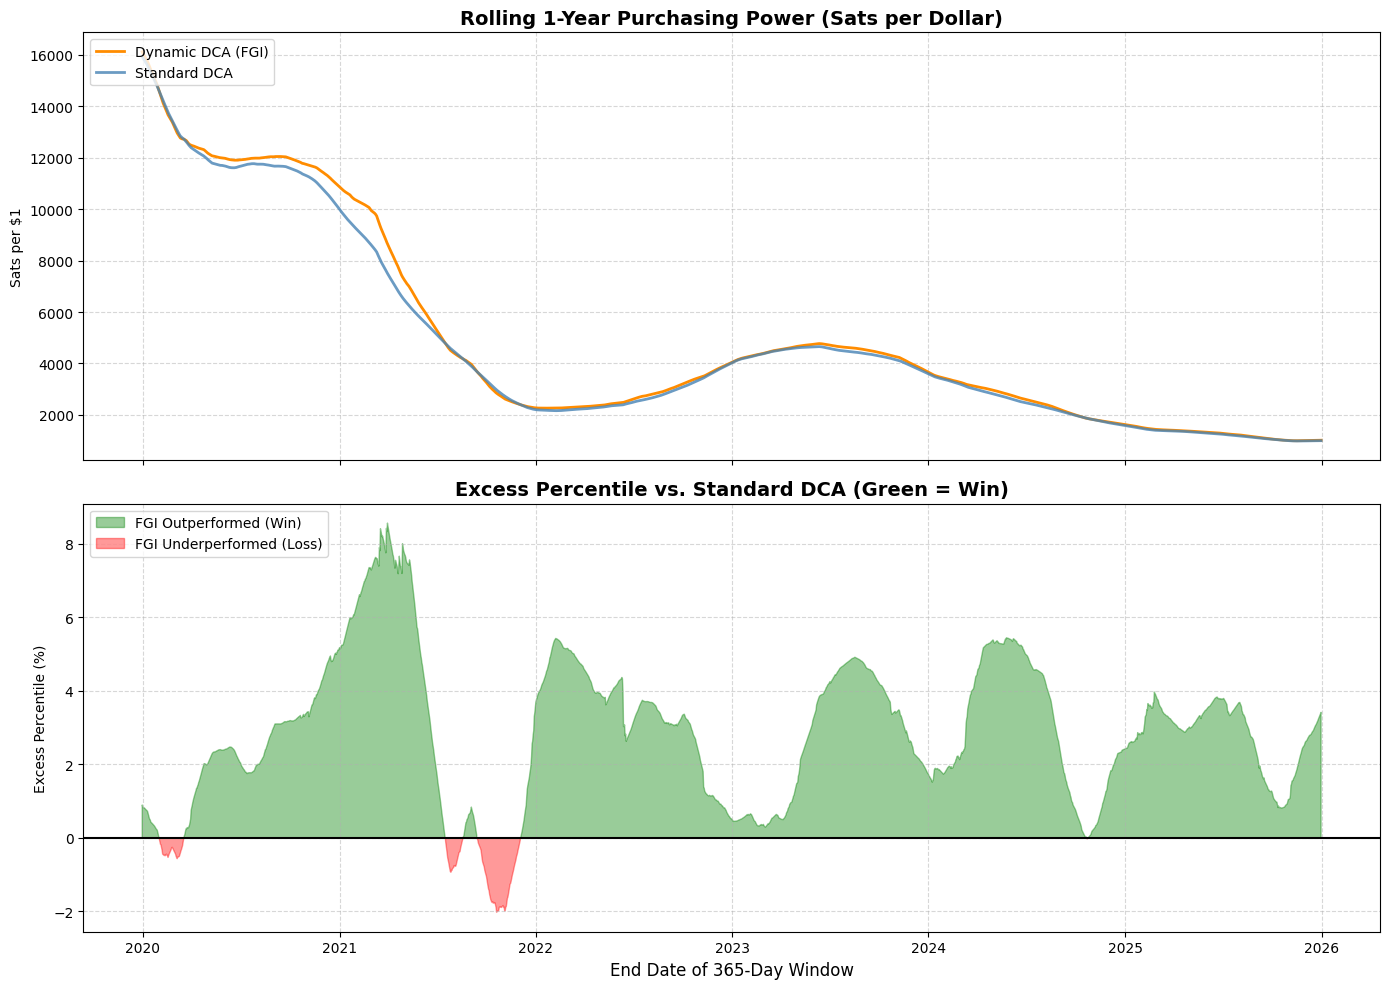

In [119]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Convert the Polars valid_windows DataFrame to Pandas for easier plotting
plot_df = valid_windows.to_pandas()
plot_df.set_index("date", inplace=True)

# Calculate the "Excess" margin (how much the dynamic strategy beat the standard one)
plot_df["excess_pct"] = plot_df["dynamic_percentile"] - plot_df["uniform_percentile"]

# 2. Set up a two-panel vertical plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# --- TOP CHART: Sats per Dollar ---
ax1.plot(plot_df.index, plot_df["dynamic_spd"], label="Dynamic DCA (FGI)", color="darkorange", linewidth=2)
ax1.plot(plot_df.index, plot_df["uniform_spd"], label="Standard DCA", color="steelblue", linewidth=2, alpha=0.8)
ax1.set_title("Rolling 1-Year Purchasing Power (Sats per Dollar)", fontsize=14, fontweight="bold")
ax1.set_ylabel("Sats per $1")
ax1.legend(loc="upper left")
ax1.grid(True, linestyle="--", alpha=0.5)

# --- BOTTOM CHART: Win/Loss Margin ---
ax2.fill_between(
    plot_df.index, plot_df["excess_pct"], 0, 
    where=(plot_df["excess_pct"] >= 0), color="green", alpha=0.4, label="FGI Outperformed (Win)"
)
ax2.fill_between(
    plot_df.index, plot_df["excess_pct"], 0, 
    where=(plot_df["excess_pct"] < 0), color="red", alpha=0.4, label="FGI Underperformed (Loss)"
)

# Add a strong zero-line to separate wins and losses
ax2.axhline(0, color="black", linewidth=1.5)
ax2.set_title("Excess Percentile vs. Standard DCA (Green = Win)", fontsize=14, fontweight="bold")
ax2.set_ylabel("Excess Percentile (%)")
ax2.set_xlabel("End Date of 365-Day Window", fontsize=12)
ax2.legend(loc="upper left")
ax2.grid(True, linestyle="--", alpha=0.5)

# Format the layout so labels don't overlap
plt.tight_layout()
plt.show()

In [141]:
import numpy as np
import pandas as pd

# =============================================================================
# Constants
# =============================================================================

# Feature column name for Fear and Greed Index
FGI_COL = "value"

# =============================================================================
# Feature Engineering
# =============================================================================

def precompute_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Passes through the FGI data. 
    Lagged 1 day to prevent look-ahead bias during backtesting.
    """
    if FGI_COL not in df.columns:
        raise KeyError(f"'{FGI_COL}' not found. Available: {list(df.columns)}")

    # Build and lag features
    features = pd.DataFrame(
        {
            FGI_COL: df[FGI_COL].shift(1).fillna(np.nan) 
        },
        index=df.index,
    )
    return features


# =============================================================================
# Weight Allocation
# =============================================================================

def get_fgi_multiplier(fgi_series: pd.Series) -> pd.Series:
    """Map raw FGI values to causal multipliers."""
    multipliers = pd.Series(1.0, index=fgi_series.index)

    # Apply discrete FGI buckets
    multipliers.loc[fgi_series <= 24] = 1.5   # Extreme Fear
    multipliers.loc[(fgi_series > 24) & (fgi_series <= 44)] = 1.2   # Fear
    multipliers.loc[(fgi_series > 44) & (fgi_series <= 55)] = 1.0   # Neutral
    multipliers.loc[(fgi_series > 55) & (fgi_series <= 75)] = 0.8   # Greed
    multipliers.loc[fgi_series > 75] = 0.5    # Extreme Greed

    return multipliers


# =============================================================================
# Weight Computation API
# =============================================================================

def compute_window_weights(
    features_df: pd.DataFrame,
    start_date: pd.Timestamp,
    end_date: pd.Timestamp,
    current_date: pd.Timestamp,
    locked_weights: np.ndarray | None = None,
) -> pd.Series:
    """
    Compute daily dynamic DCA weights for a specific window.
    Uses exact retroactive normalization from the EDA backtest.
    """
    # 1. Isolate the specific window
    mask = (features_df.index >= start_date) & (features_df.index <= end_date)
    window_data = features_df.loc[mask].copy()

    # Handle future dates missing from features_df (pad with placeholders)
    full_range = pd.date_range(start=start_date, end=end_date, freq="D")
    if len(window_data) < len(full_range):
        window_data = window_data.reindex(full_range)

    # 2. Map causal raw signals
    if FGI_COL in window_data.columns:
        raw_weights = get_fgi_multiplier(window_data[FGI_COL])
    else:
        raw_weights = pd.Series(1.0, index=window_data.index)

    # 3. Allocation (Backtest vs Production)
    if locked_weights is None:
        # BACKTEST MODE: Retroactive Window Normalization
        # Mathematically guarantees weights sum exactly to 1.0
        normalized_weights = raw_weights / raw_weights.sum()
        
    else:
        # PRODUCTION MODE: Respect locked past weights
        n_total = len(raw_weights)
        n_past = min(len(locked_weights), n_total)
        w = np.zeros(n_total)

        # Lock in historical weights pulled from database
        w[:n_past] = locked_weights[:n_past]
        remaining_budget = max(1.0 - w[:n_past].sum(), 0.0)

        # Distribute the remaining budget over future dates based on their assumed raw multipliers
        future_raw = raw_weights.iloc[n_past:].values
        if len(future_raw) > 0:
            future_sum = future_raw.sum()
            if future_sum > 0:
                w[n_past:] = (future_raw / future_sum) * remaining_budget
            else:
                w[n_past:] = remaining_budget / len(future_raw)

        normalized_weights = pd.Series(w, index=raw_weights.index)

    return normalized_weights

In [142]:
import pandas as pd
import numpy as np

# 1. Convert Polars DataFrame to Pandas and set Date index
features_df = merged_fgi_btc.to_pandas()
features_df['date'] = pd.to_datetime(features_df['date'])
features_df.set_index('date', inplace=True)

# Isolate the date range to match our backtest window
mask = (features_df.index >= '2019-01-01') & (features_df.index <= '2025-12-31')
features_df = features_df.loc[mask].copy()

# Keep a separate reference to the daily prices
prices = features_df['PriceUSD']

# 2. Run the iterative backtest using the new module function
window_size = 365
results = []

print("Running window-by-window backtest simulation... (this may take a few seconds)")

# Loop through every possible 365-day window in the dataset
for i in range(len(features_df) - window_size + 1):
    
    # Define start and end boundaries for this specific window
    window_start = features_df.index[i]
    window_end = features_df.index[i + window_size - 1]
    
    # -------------------------------------------------------------------------
    # CALLING YOUR NEW MODULE LOGIC:
    # -------------------------------------------------------------------------
    # We pass current_date = window_end and locked_weights = None to simulate 
    # the retroactive backtest allocation mode.
    weights = compute_window_weights(
        features_df=features_df,
        start_date=window_start,
        end_date=window_end,
        current_date=window_end,
        locked_weights=None
    )
    
    # Isolate prices for this window and calculate Sats per Dollar
    window_prices = prices.loc[window_start:window_end]
    inv_price = 100_000_000 / window_prices
    
    # Calculate Uniform SPD (Baseline: 1/365 weight every day)
    uniform_weight = 1.0 / window_size
    uniform_spd = (inv_price * uniform_weight).sum()
    
    # Calculate Dynamic SPD (Using the normalized weights from your function)
    dynamic_spd = (inv_price * weights).sum()
    
    # Calculate Window Extremes for Percentiles
    min_spd = inv_price.min()
    max_spd = inv_price.max()
    
    uniform_pct = ((uniform_spd - min_spd) / (max_spd - min_spd)) * 100
    dynamic_pct = ((dynamic_spd - min_spd) / (max_spd - min_spd)) * 100
    
    # Store the results
    results.append({
        'date': window_end, # The date the 1-year window completes
        'uniform_spd': uniform_spd,
        'dynamic_spd': dynamic_spd,
        'uniform_percentile': uniform_pct,
        'dynamic_percentile': dynamic_pct
    })

# 3. Assemble the final evaluation DataFrame
dca_df_sim = pd.DataFrame(results).set_index('date')

# 4. Evaluate the Output
total_windows = len(dca_df_sim)
wins = (dca_df_sim['dynamic_percentile'] > dca_df_sim['uniform_percentile']).sum()
win_rate = (wins / total_windows) * 100

dyn_spd_mean = dca_df_sim["dynamic_spd"].mean()
dyn_spd_median = dca_df_sim["dynamic_spd"].median()
dyn_pct_mean = dca_df_sim["dynamic_percentile"].mean()
dyn_pct_median = dca_df_sim["dynamic_percentile"].median()
mean_excess = (dca_df_sim['dynamic_percentile'] - dca_df_sim['uniform_percentile']).mean()

print(f"\nBacktesting date range: 2019-12-31 to 2025-12-31 ({total_windows} total windows)")
print("\nAggregated Metrics for Dynamic DCA:")
print(f"  SPD: mean={dyn_spd_mean:.2f}, median={dyn_spd_median:.2f}")
print(f"  Percentile: mean={dyn_pct_mean:.2f}%, median={dyn_pct_median:.2f}%")
print(f"\nSummary: {total_windows - wins}/{total_windows} underperformed ({win_rate:.2f}% win rate)")

if win_rate >= 50.0:
    print("✅ Strategy meets performance requirement (≥ 50% win rate vs. uniform DCA).")
else:
    print("❌ Strategy failed performance requirement (< 50% win rate).")

print(f"\nFinal Metrics Preview:")
print(f"  Mean Excess: {mean_excess:+.2f}%")

Running window-by-window backtest simulation... (this may take a few seconds)

Backtesting date range: 2019-12-31 to 2025-12-31 (2193 total windows)

Aggregated Metrics for Dynamic DCA:
  SPD: mean=4902.95, median=3417.74
  Percentile: mean=41.11%, median=41.74%

Summary: 163/2193 underperformed (92.57% win rate)
✅ Strategy meets performance requirement (≥ 50% win rate vs. uniform DCA).

Final Metrics Preview:
  Mean Excess: +2.83%


In [144]:
features_df

,AdrActCnt,AdrBalCnt,AssetCompletionTime,AssetEODCompletionTime,BlkCnt,CapMVRVCur,CapMrktCurUSD,CapMrktEstUSD,FeeTotNtv,FlowInExNtv,...,ReferenceRateUSD,SplyCur,SplyExNtv,SplyExUSD,SplyExpFut10yr,TxCnt,TxTfrCnt,volume_reported_spot_usd_1d,value,value_classification
date,,,,,,,,,,,,,,,,,,,,,
2019-01-01,433715.0,22399091.0,1.614337e+09,1.614337e+09,149.0,0.839104,6.648014e+10,NaN,11.263483,12398.804912,...,NaN,1.745748e+07,1.533069e+06,5.838109e+09,2.039408e+07,235813.0,448759.0,6.651384e+08,24,Extreme Fear
2019-01-02,578607.0,22376168.0,1.614337e+09,1.614337e+09,151.0,0.859073,6.806006e+10,NaN,18.195239,25609.499964,...,NaN,1.745937e+07,1.529663e+06,5.962930e+09,2.039432e+07,271103.0,545632.0,9.073312e+08,30,Fear
2019-01-03,598436.0,22383153.0,1.614337e+09,1.614337e+09,155.0,0.834871,6.608036e+10,NaN,19.071180,26211.564461,...,NaN,1.746130e+07,1.522298e+06,5.760968e+09,2.039456e+07,287081.0,599287.0,7.419055e+08,33,Fear
2019-01-04,580495.0,22398175.0,1.614337e+09,1.614337e+09,149.0,0.844727,6.684070e+10,NaN,19.356800,26932.229289,...,NaN,1.746317e+07,1.519753e+06,5.816893e+09,2.039479e+07,283490.0,581832.0,9.243672e+08,48,Neutral
2019-01-05,519070.0,22413983.0,1.614337e+09,1.614337e+09,163.0,0.838567,6.634357e+10,NaN,12.551464,21120.885749,...,NaN,1.746520e+07,1.525655e+06,5.795374e+09,2.039505e+07,269637.0,533367.0,8.254437e+08,36,Fear
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-27,569638.0,55728140.0,1.766890e+09,1.766890e+09,136.0,1.561130,1.751089e+12,1.751067e+12,2.079782,9435.308947,...,NaN,1.996785e+07,2.504008e+06,2.195900e+11,2.082452e+07,475008.0,1027864.0,3.260594e+09,23,Extreme Fear
2025-12-28,572908.0,55752466.0,1.766977e+09,1.766977e+09,155.0,1.562371,1.752174e+12,1.752146e+12,2.155405,9847.439706,...,NaN,1.996833e+07,2.506026e+06,2.198979e+11,2.082464e+07,540696.0,1155370.0,4.029677e+09,24,Extreme Fear
2025-12-29,693511.0,55767043.0,1.767065e+09,1.767065e+09,154.0,1.551844,1.739953e+12,1.739927e+12,2.806141,32455.348312,...,NaN,1.996881e+07,2.504439e+06,2.182206e+11,2.082476e+07,548253.0,1175491.0,1.586258e+10,24,Extreme Fear
